In this notebook we explore the induced matching taking into account the sizes of components that get merged. In a nutshell, whenever two components are being merged, the component that survives is always the big one.

In [1]:
import numpy as np
import tdqual.topological_data_quality_0 as tdqual

import matplotlib.pyplot as plt
import matplotlib as mpl

import os

plots_dir = "columns"
os.makedirs(plots_dir, exist_ok=True)

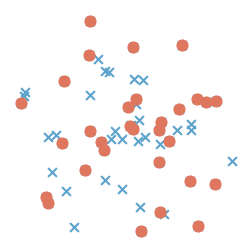

In [2]:
RandGen = np.random.default_rng(2)
# # Generate Random Sample
Z = tdqual.sampled_circle(0,2,60, RandGen)
X_indices = RandGen.choice(Z.shape[0], 30, replace=False)
Z[X_indices]+=[0,0]
X = Z[X_indices]
# Plot point cloud
fig, ax = plt.subplots(ncols=1, figsize=(3,3))
ax.scatter(X[:,0], X[:,1], color=mpl.colormaps["RdBu"](0.3/1.3), s=60, marker="o", zorder=2)
ax.scatter(Z[:,0], Z[:,1], color=mpl.colormaps["RdBu"](1/1.3), s=40, marker="x", zorder=1)
ax.set_axis_off()
plt.savefig(plots_dir + "points_0.png")

In [3]:
# Sort indices of points in Z, so that 
X_compl = np.ones(Z.shape[0], dtype="bool")
X_compl[X_indices] = False
Z = np.vstack((Z[X_indices], Z[X_compl]))
X_indices = range(len(X_indices))
X = Z[X_indices]

In [4]:
from tdqual.topological_data_quality_0 import compute_tmt_pairs, mst_edge_filtration, get_inclusion_matrix

filtration_list_X, pairs_arr_X = mst_edge_filtration(X) # MST(X)
filtration_list_Z, pairs_arr_Z = mst_edge_filtration(Z) # MST(Z)
TMT_X_pairs = compute_tmt_pairs(filtration_list_X, pairs_arr_X, subset_size=X.shape[0])
TMT_Z_pairs = compute_tmt_pairs(filtration_list_Z, pairs_arr_Z, subset_size=X.shape[0])
indices_X_Z = np.max(TMT_Z_pairs, axis=1)<X.shape[0]
TMT_X_Z_pairs = TMT_Z_pairs[indices_X_Z]
indices_X_Z = np.nonzero(indices_X_Z)[0]

In [9]:
TMT_X_pairs

array([[18, 16],
       [ 7,  5],
       [29, 19],
       [26, 12],
       [ 6,  3],
       [23,  3],
       [20,  8],
       [25, 19],
       [27, 12],
       [16,  8],
       [17,  3],
       [ 9, 19],
       [19,  3],
       [28, 10],
       [11,  1],
       [ 8,  3],
       [ 0, 12],
       [14, 12],
       [13,  2],
       [12,  3],
       [24,  2],
       [ 1,  3],
       [15, 10],
       [10,  3],
       [ 4,  2],
       [ 5,  3],
       [ 2,  3],
       [21,  3],
       [22,  3]])

In [5]:
TMT_X_Z_pairs

array([[16, 18],
       [ 7,  5],
       [29, 19],
       [ 8, 20],
       [26, 12],
       [ 6,  3],
       [23,  3],
       [25, 19],
       [12, 18],
       [20, 18],
       [19, 18],
       [27, 18],
       [ 9, 18],
       [17, 18],
       [ 3, 18],
       [10, 28],
       [ 0, 28],
       [11,  1],
       [28, 18],
       [13, 18],
       [ 5, 18],
       [14, 18],
       [24, 18],
       [ 4, 18],
       [ 2, 18],
       [15, 18],
       [ 1, 18],
       [21, 18],
       [22, 18]])

In [6]:
FX = get_inclusion_matrix(TMT_X_pairs, TMT_X_Z_pairs) # Associated matrix

---
[-1, 5, 1, 17, 0, 12, 13, 14, 8, 24, 25, 26, 23, 20, 21, 19, 10, 9, 3, 27, 28, 6, 22, 7, 4, 11, 15, 16, 18, 2]
[18, 16]
piv:18
3
[np.int64(8), 16, 18, np.int64(20)]
piv:20
28
[np.int64(8), 16, np.int64(20), np.int64(22)]
piv:22
22
[np.int64(8), 16, np.int64(18), np.int64(20), np.int64(22), np.int64(24)]
piv:24
4
[np.int64(8), np.int64(12), 16, np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26)]
piv:26
15
[np.int64(8), np.int64(10), np.int64(12), 16, np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28)]
piv:28
18
[np.int64(8), np.int64(10), np.int64(12), 16, np.int64(20), np.int64(22), np.int64(24), np.int64(26)]
piv:26
15
[np.int64(8), np.int64(12), 16, np.int64(20), np.int64(22), np.int64(24), np.int64(26), np.int64(28)]
piv:28
18
[np.int64(8), np.int64(12), 16, np.int64(18), np.int64(20), np.int64(22), np.int64(24), np.int64(26)]
piv:26
15
[np.int64(8), np.int64(10), np.int64(12), 16, np.int64(18), np.int64(20), np.int64(22), np.int

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



KeyboardInterrupt: 

In [ ]:
FX

In [5]:
pairs_arr_X

array([[16, 18],
       [ 5,  7],
       [19, 29],
       [12, 26],
       [ 3,  6],
       [ 6, 23],
       [ 8, 20],
       [19, 25],
       [12, 27],
       [ 8, 18],
       [ 3, 17],
       [ 9, 25],
       [17, 29],
       [10, 28],
       [ 1, 11],
       [16, 19],
       [ 0, 26],
       [14, 27],
       [ 2, 13],
       [12, 18],
       [13, 24],
       [ 1,  9],
       [15, 28],
       [ 1, 28],
       [ 4, 13],
       [ 0,  7],
       [ 4, 20],
       [21, 24],
       [ 4, 22]])

In [10]:
A =np.array([3,3,5,2,2,2,1])

In [14]:
if np.sum(A==3)<np.sum(A==2):
    print("hello")

hello
